# CRVSE Phase B - Ensemble rPPG - CRVSEInceptionNet 1D (Round 2) part 1 - ensemble only (1D).

### What this notebook does

Trains CRVSEInceptionNet on ensemble rPPG signals (POS + CHROM + GREEN)

Runs **one Optuna study** - `ensemble_only` - pre-fused quality-weighted ensemble signal as single input channel.


## 1. Imports and Config



In [1]:
import h5py, torch, os, optuna, json
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy import stats
from scipy.signal import resample
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict, Counter
from tqdm import tqdm
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

#  Paths 
H5_PATHS = {
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/mcd_rppg_ensemble.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_rppg_ensemble.h5",
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_phys_ensemble.h5",
    "ecg_fitness": "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ecg_fitness_ensemble.h5"
}

# SQI gates per dataset 
# Thresholds calibrated during preprocessing (see NB06/NB07/NB08).
# MCD-rPPG 0.10 : recalibrated (ensemble scale differs from POS-only)
# UBFC-rPPG 0.07: original threshold, clean lab conditions
# UBFC-Phys 0.05: lowered - 35fps + 1024x1024 + stress tasks lower spectral SQI
DATASET_SQI_THRESHOLDS = {
    "mcd_rppg"  : 0.10,
    "ubfc_rppg" : 0.07,
    "ubfc_phys" : 0.05,
    "ecg_fitness" : 0.07
}

# Fixed config
MODEL_NAME = "CRVSEInceptionNet_Ensemble"
INPUT_MODE = "ensemble_only"
IN_CHANNELS = 1 # pre-fused quality weighted ensemble
STUDY_NAME = "inception_b__ens_single"

HR_MIN = 40.0
HR_MAX = 180.0
MAX_NAN_FRAC = 0.10
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config  
N_TRIALS = 40
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5


print(f"Device : {DEVICE}")
print(f"Trials : {N_TRIALS} | Max epochs/trial: {N_EPOCHS}")
print(f"Datasets : {list(H5_PATHS.keys())}")
print(f"Input mode : {INPUT_MODE} ({IN_CHANNELS} channel)")
print(f"SQI thresholds : {DATASET_SQI_THRESHOLDS}")



Device : cuda
Trials : 40 | Max epochs/trial: 50
Datasets : ['mcd_rppg', 'ubfc_rppg', 'ubfc_phys', 'ecg_fitness']
Input mode : ensemble_only (1 channel)
SQI thresholds : {'mcd_rppg': 0.1, 'ubfc_rppg': 0.07, 'ubfc_phys': 0.05, 'ecg_fitness': 0.07}


## 2. Window Extractor

In [2]:
def extract_windows(signals: dict, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec:int,
                   target_frames: int, max_nan_frac: float, hr_min: float, hr_max: float) -> list:
    """
    Extract sliding windows from one recording.
    
    Returns:
        list of dicts, each containing:
            pos_win, chrom_win, green_win, ensemble_win: (target_frames,) float32
            hr_label: scalar float, nanmean of hr_cont over window.
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(hr_cont)
    results = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames
        hr_win = hr_cont[start:end]

        # Gate 1: NaN fraction on HR label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue

        # Gate 2: scalar HR label
        hr_label = float(np.nanmean(hr_win))
        if not (hr_min <= hr_label <= hr_max):
            continue

        # Process each signal channel
        win_dict = {}
        skip = False

        for key in ("pos", "chrom", "green", "ensemble"):
            sig_win = signals[key][start:end]

            # Gate 3: NaN on signal
            if np.any(np.isnan(sig_win)):
                skip = True
                break

            # Resample to fixed length
            if len(sig_win) != target_frames:
                sig_win = resample(sig_win, target_frames).astype(np.float32)

            # Gate 4: flat signal (std < 1e-6 means no pulse information)
            std = sig_win.std()
            if std < 1e-6:
                skip = True
                break

            # Z-score per window per channel
            sig_win = ((sig_win - sig_win.mean()) / std).astype(np.float32)
            win_dict[f"{key}_win"] = sig_win

        if skip:
            continue

        win_dict["hr_label"] = hr_label
        results.append(win_dict)

    return results

## 3. Index Builder

Reads all HDF5 files once and builds a flat list of window dicts. All four signal channels (POS, CHROM, GREEN, ensemble) are stored per window. SQI gating is applied per dataset before windowing.

In [3]:
def build_index(h5_paths: dict, sqi_thresholds: dict, window_sec: int, stride_sec: int, target_frames: int, 
                max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Builds flat window index from all ensemble HDF5 files.
    
    SQI gate: recordings with sqi_ensemble < sqi_thresholds[dataset] are skipped.
    Threshold is dataset-specific - calibrated in preprocessing NBs.
    
    Returns:
        samples : list of window dicts (all_channels pre-computed)
        subject_keys : sorted list of unique subject keys for split.
    """
    samples = []
    subject_keys = set()
    skipped_sqi = 0

    for dataset_name, path in h5_paths.items():
        if not os.path.exists(path):
            print(f"[WARN] Not found, skipping: {path}")
            continue

        sqi_gate = sqi_thresholds.get(dataset_name, 0.07)

        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]

                    # SQI gate - skip recording before any signal read
                    sqi_ens = float(rec.attrs.get("sqi_ensemble", 1.0))
                    if sqi_ens < sqi_gate:
                        skipped_sqi += 1
                        continue

                    fps = float(rec.attrs["fps"])
                    hr_cont = rec["hr_continuous"][:]

                    # Read all four signals - stored for both study modes
                    signals = {
                        "pos" : rec["rppg_pos"][:],
                        "chrom" : rec["rppg_chrom"][:],
                        "green" : rec["rppg_green"][:],
                        "ensemble" : rec["rppg_ensemble"][:]
                    }

                    wins = extract_windows(signals, hr_cont, fps, window_sec, stride_sec, 
                                           target_frames, max_nan_frac, hr_min, hr_max)
                    for w in wins:
                        w["subject_key"] = subj_key
                        w["dataset"] = dataset_name
                        samples.append(w)

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    print(f"Recordings skipped (SQI) : {skipped_sqi}")

    # Per-dataset breakdown
    ds_counts = Counter(s["dataset"] for s in samples)
    print("\nPer-dataset window counts:")
    for ds, n in sorted(ds_counts.items()):
        print(f"{ds:<15} : {n:>6} windows")

    return samples, sorted(subject_keys)    

## 4. Subject-Level Train/Val/Test split

In [4]:
def subject_split(subject_keys: list, train_frac: float = 0.7, val_frac: float = 0.15, seed: int = 42) -> tuple:
    """
    Subject level stratified split. 
    test_frac = 1 - train_frac - val_frac
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys = set(keys[:n_train])
    val_keys = set(keys[n_train : n_train + n_val])
    test_keys = set(keys[n_train + n_val:])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subject : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset Class

Assemble the input tensor from pre-built window dicts based on `input_mode`:

* `ensemble_only` -> `(1, 240)`

In [5]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase b ensemble rPPG -> HR estimation.
    
    Args:
        samples : list of window dicts from build_index()
        subject_set : set of subject_key strings to include (train/val/test)
        input_mode : `ensemble_only` | `multichannel` controls which signals are assembled into the input tensor.
    """
    def __init__(self, samples: list, subject_set: set, input_mode: str = "multichannel") -> None:
        self.input_mode = input_mode
        self.items = [s for s in samples if s["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows (mode={input_mode})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple:
        item = self.items[idx]

        if self.input_mode == "ensemble_only":
            # Shape: (1, 240) - single pre-fused channel 
            signal = torch.tensor(item["ensemble_win"], dtype=torch.float32).unsqueeze(0)
        else:
            # Shape: (3, 240) 0 independent algorithm outputs
            signal = torch.stack([
                torch.tensor(item["pos_win"], dtype=torch.float32),
                torch.tensor(item["chrom_win"], dtype=torch.float32),
                torch.tensor(item["green_win"], dtype=torch.float32)
            ])

        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label

## 6. Model Architecture

In [6]:
class InceptionBlock1d(nn.Module):
    """
    Parallel multi-scale convolutions - captures rPPG features at shor (morphology),
    medium (beat), and long (rhythm) scales.
    """
    def __init__(self, in_channels : int, out_channels: int, dropout: float = 0.2) -> None:
        super().__init__()

        # Three parallel branches at different scales
        self.branch_short = self._branch(in_channels, out_channels, kernel=3)
        self.branch_medium = self._branch(in_channels, out_channels, kernel=7)
        self.branch_long = self._branch(in_channels, out_channels, kernel=15)

        # MaxPool branch - caputres amplitude peaks
        self.branch_pool = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, out_channels, kernel_size=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )

        self.dropout = nn.Dropout(dropout)
        # Output channels = out_channels * 4 (3 conv + 1 pool)

    def _branch(self, in_ch: int, out_ch: int, kernel: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        s = self.branch_short(x)
        m = self.branch_medium(x)
        l = self.branch_long(x)
        p = self.branch_pool(x)
        out = torch.cat([s, m, l, p], dim=1)
        return self.dropout(out)


class CRVSEInceptionNet1D(nn.Module):
    """
    Stacked Inception blocks for rPPG -> HR regression.
    Head width scales automatically with branch_channels:
        head_dim = branch_channels * 2
        ch_out (512) -> head_dim (256) -> 1 for branch_channels = 128
        ch_out (64) -> head_dim (32) -> 1 for branch_channels = 16
    """
    def __init__(
        self,
        in_channels : int = 1,
        branch_channels : int = 16,  
        n_blocks : int = 3,
        dropout : float = 0.2,
        hr_min : float = 40.0,
        hr_max : float = 180.0,
    ) -> None:
        super().__init__()

        self.hr_min = hr_min
        self.hr_max = hr_max

        
        head_dim = branch_channels * 2 
        ch_out = branch_channels * 4
        blocks = []
        current_ch = in_channels
        
        for _ in range(n_blocks):
            blocks.append(InceptionBlock1d(current_ch, branch_channels, dropout))
            current_ch = ch_out

        self.inception = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Linear(ch_out, head_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.inception(x) # (B, ch_out, 240)
        out = out.mean(dim=-1) # (B, ch_out) - GAP
        out = self.head(out) # (B, 1)
        out = out.squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

In [7]:
# Model sanity check
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
    
print("Single-channel sanity check (ensemble_only):")
# Instantiate model
m1 = CRVSEInceptionNet1D(
    in_channels = 1,
    branch_channels = 16,
    n_blocks = 3,
    dropout = 0.2,
    hr_min = HR_MIN,
    hr_max = HR_MAX,
)

x1 = torch.randn(32, 1, 240)
with torch.inference_mode():
    
    o1 = m1(x1)
print(f"Input : {x1.shape}")
print(f"Output : {o1.shape}")
print(f"Params : {count_parameters(m1):,}")
print(m1)


Single-channel sanity check (ensemble_only):
Input : torch.Size([32, 1, 240])
Output : torch.Size([32])
Params : 56,353
CRVSEInceptionNet1D(
  (inception): Sequential(
    (0): InceptionBlock1d(
      (branch_short): Sequential(
        (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (branch_medium): Sequential(
        (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
        (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (branch_long): Sequential(
        (0): Conv1d(1, 16, kernel_size=(15,), stride=(1,), padding=(7,))
        (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (branch_pool): Sequential(
        (0): MaxPool1d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
  

## 7. Data Preparation

Single `build_index` call - all four signals read once. 

In [8]:
all_samples, all_subject_keys = build_index(
    h5_paths = H5_PATHS,
    sqi_thresholds = DATASET_SQI_THRESHOLDS,
    window_sec = 8,
    stride_sec = 4,
    target_frames = 240,
    max_nan_frac = MAX_NAN_FRAC,
    hr_min = HR_MIN,
    hr_max = HR_MAX
)

train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.7, val_frac=0.15, seed=SEED)

Total windows extracted : 19052
Total unique subjects : 479
Recordings skipped (SQI) : 246

Per-dataset window counts:
ecg_fitness     :    882 windows
mcd_rppg        :  11283 windows
ubfc_phys       :   6239 windows
ubfc_rppg       :    648 windows
Train subjects : 335
Val subjects : 71
Test subject : 73


## 8. Evaluation Functions

In [9]:
def compute_subject_level_metrics(preds : np.ndarray, labels : np.ndarray, subject_ids: list) -> dict:
    """
    Aggregate window predictions per subject (mean),
    Compute metrics across subjects.
    Subject-level MAE is the standard rPPG benchmark metric.
    """
    subj_preds = defaultdict(list)
    subj_labels = defaultdict(list)

    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])

    diff = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r, _ = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())

    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")

    return {
        "subj_mae": mae, 
        "subj_rmse": rmse,
        "subj_r": r, 
        "ba_bias": ba_bias,
        "ba_loa_lo": ba_bias - 1.96*ba_sd,
        "ba_loa_hi": ba_bias + 1.96*ba_sd,
        "n_subjects": len(subj_pred_mean),
    }


def coverage_metrics(preds : np.ndarray, labels: np.ndarray,) -> None:
    abs_err = np.abs(preds - labels)
    for threshold in [5, 10, 15]:
        pct = float(np.mean(abs_err < threshold) * 100)
        print(f"|error| < {threshold:>2} BPM : {pct:.1f}% of windows")


def per_dataset_metrics(preds : np.ndarray, labels : np.ndarray, dataset_ids: list) -> None:
    datasets = sorted(set(dataset_ids))
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")

    for ds in datasets:
        mask = np.array([d == ds for d in dataset_ids])
        p, l = preds[mask], labels[mask]
        if len(p) < 2:
            continue
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        r, _  = stats.pearsonr(p, l)
        print(f"{ds:<15} {len(p):>5} {mae:>8.2f} {rmse:>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds : np.ndarray, labels: np.ndarray) -> None:
    bins = [(40, 65, "bradycardia/low"),
            (65, 85, "normal low"),
            (85, 100, "normal high"),
            (100, 180, "tachycardia/exercise")]

    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")

    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2:
            continue
        p, l = preds[mask], labels[mask]
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        print(f"{label:<22} {mask.sum():>5} {mae:>8.2f} {rmse:>8.2f}")


def full_evaluation(preds: np.ndarray, labels : np.ndarray, subject_ids: list, dataset_ids: list, model_name : str = "Model") -> None:

    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")

    # Window-level
    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    ss_res = np.sum(diff ** 2)
    ss_tot = np.sum((labels - labels.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96 * ba_sd
    loa_hi = ba_bias + 1.96 * ba_sd

    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f}  (p={pval:.4f})")
    print(f"R² : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{loa_lo:.2f}, {loa_hi:.2f}] BPM")

    # Coverage
    print()
    coverage_metrics(preds, labels)

    # Subject-level
    compute_subject_level_metrics(preds, labels, subject_ids)

    # Per-dataset
    per_dataset_metrics(preds, labels, dataset_ids)

    # HR-stratified
    hr_stratified_metrics(preds, labels)


## 9. Objective Factory

In [10]:
def make_objective(in_channels: int, train_loader: DataLoader, val_loader: DataLoader) -> callable:
    """Returns an Optuna objective bound to the given in_channels and DataLoaders."""
    def objective(trial: optuna.Trial) -> float:
        # Tier 1 — regularisation & optimiser
        lr           = trial.suggest_float("lr",           1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout      = trial.suggest_float("dropout",      0.1,  0.4)
        huber_delta  = trial.suggest_float("huber_delta",  1.0,  10.0)

        # Tier 2 — architecture
        branch_channels = trial.suggest_categorical("branch_channels", [16, 32, 64, 128])
        n_blocks        = trial.suggest_int("n_blocks", 2, 6)

        model = CRVSEInceptionNet1D(
            in_channels     = in_channels,
            branch_channels = branch_channels,
            n_blocks        = n_blocks,
            dropout         = dropout,
            hr_min          = HR_MIN,
            hr_max          = HR_MAX,
        ).to(DEVICE)

        loss_fn   = nn.HuberLoss(delta=huber_delta)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr / 100)

        best_val_mae = float("inf")

        # FIX: tqdm epoch bar — shows live progress inside every trial
        epoch_bar = tqdm(range(1, N_EPOCHS + 1),
                         desc=f"Trial {trial.number:>3}",
                         unit="ep", leave=False)

        for epoch in epoch_bar:
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = loss_fn(model(signals), labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    total_mae += torch.mean(torch.abs(model(signals) - labels)).item()
            val_mae = total_mae / len(val_loader)
            scheduler.step()

            if val_mae < best_val_mae:
                best_val_mae = val_mae

            epoch_bar.set_postfix({"val_mae": f"{val_mae:.2f}"})
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_mae

    return objective

print("make_objective factory defined.")

make_objective factory defined.


## 10. Study - `ensemble_only` (1 channel)
Baseline: pre-fused quality-weighted ensemble signal as single input channel. Establishes whether the ensemble fusion itself carries enough information.

In [11]:
train_ds = CRVSEDataset(all_samples, train_keys, input_mode=INPUT_MODE)
val_ds = CRVSEDataset(all_samples, val_keys,   input_mode=INPUT_MODE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# FIX: n_startup_trials=1  (was 5, larger than N_TRIALS=2 → pruner never fired)
study = optuna.create_study(
    direction   = "minimize",
    sampler     = TPESampler(seed=SEED),
    pruner      = MedianPruner(n_startup_trials=1, n_warmup_steps=PRUNER_WARMUP, interval_steps=1),
    study_name  = STUDY_NAME,
)

def progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
    status = "PRUNED" if trial.state == optuna.trial.TrialState.PRUNED else f"{trial.value:.2f} BPM"
    best   = f"{study.best_value:.2f} BPM" if study.best_value is not None else "—"
    print(
        f"Trial {trial.number:>3} | val MAE : {status:<12} | best : {best} | "
        f"lr={trial.params.get('lr','?'):.1e}  drop={trial.params.get('dropout','?'):.2f}  "
        f"n_blocks={trial.params.get('n_blocks','?')}  branch_ch={trial.params.get('branch_channels','?')}"
    )

print(f"Starting {STUDY_NAME} — {N_TRIALS} trials, up to {N_EPOCHS} epochs each")
print(f"Pruner : MedianPruner (n_startup=1, warmup={PRUNER_WARMUP})")
print("-" * 72)

study.optimize(
    make_objective(IN_CHANNELS, train_loader, val_loader),
    n_trials   = N_TRIALS,
    callbacks  = [progress_callback],
    show_progress_bar = True,
)

print("\n" + "=" * 60)
print(f"STUDY COMPLETE — {INPUT_MODE}")
print("=" * 60)
print(f"Best val MAE : {study.best_value:.2f} BPM")
print(f"Best trial   : #{study.best_trial.number}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<20} : {v}")
n_ok  = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
n_pr  = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f"Completed : {n_ok}   Pruned : {n_pr}")


Dataset size: 12954 windows (mode=ensemble_only)
Dataset size: 2992 windows (mode=ensemble_only)
Starting inception_b__ens_single — 40 trials, up to 50 epochs each
Pruner : MedianPruner (n_startup=1, warmup=5)
------------------------------------------------------------------------


  0%|          | 0/40 [00:00<?, ?it/s]


Trial   0: 100%|██████████| 50/50 [37:41<00:00, 45.26s/ep, val_mae=9.15]
                                                                        

Trial   0 | val MAE : 8.93 BPM     | best : 8.93 BPM | lr=2.4e-04  drop=0.32  n_blocks=5  branch_ch=128



Trial   1:  28%|██▊       | 14/50 [08:34<20:34, 34.29s/ep, val_mae=9.43]
                                                                        

...

Trial  37 | val MAE : PRUNED       | best : 8.77 BPM | lr=3.7e-04  drop=0.14  n_blocks=3  branch_ch=128



Trial  38:   8%|▊         | 4/50 [01:30<13:54, 18.14s/ep, val_mae=10.71]
                                                                        

Trial  38 | val MAE : PRUNED       | best : 8.77 BPM | lr=3.2e-04  drop=0.22  n_blocks=6  branch_ch=64



Trial  39:   8%|▊         | 4/50 [00:29<04:34,  5.97s/ep, val_mae=11.86]
                                                                        

Trial  39 | val MAE : PRUNED       | best : 8.77 BPM | lr=4.6e-04  drop=0.33  n_blocks=4  branch_ch=32

STUDY COMPLETE — ensemble_only
Best val MAE : 8.77 BPM
Best trial   : #21
Best params:
  lr                   : 0.00040631646340337616
  weight_decay         : 0.0037007977082550887
  dropout              : 0.2312128336226637
  huber_delta          : 4.662635545649153
  branch_channels      : 128
  n_blocks             : 4
Completed : 3   Pruned : 37


## 11. Study Results Plot

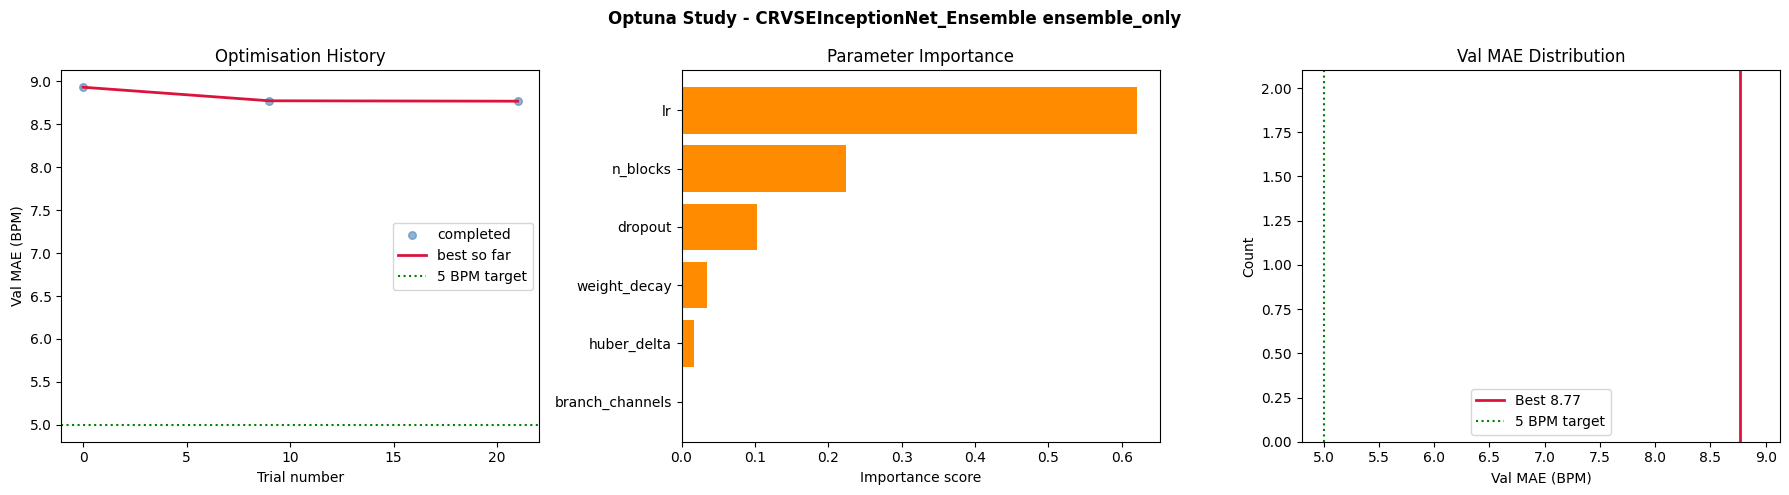

In [12]:
def plot_optuna_results(study: optuna.Study, model_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value for t in trials]
    best_so_far = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"Optuna Study - {model_name}", fontweight="bold")

    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_so_far, color="crimson", lw=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial number")
    axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History")
    axes[0].legend()

    try:
        importances = optuna.importance.get_param_importances(study)
        top_params = list(importances.items())[:6]
        params, imps = zip(*top_params)
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance score")
        axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Importance\nnot available", ha="center", va="center", transform=axes[1].transAxes)

    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", lw=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[2].set_xlabel("Val MAE (BPM)")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Val MAE Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


plot_optuna_results(study, f"{MODEL_NAME} ensemble_only")

## 12. Final Training on Best Configuration

Retrains on train + val combined using the winning study's best hyperparameters. Evaluates on held-out test set.

In [13]:
p = study.best_params
best_n_epochs = study.best_trial.last_step  # epochs the best trial actually ran

print("=" * 55)
print(f"Final retraining : {MODEL_NAME} ({INPUT_MODE})")
print(f"Best trial : #{study.best_trial.number}")
print(f"Best val MAE : {study.best_value:.2f} BPM")
print(f"Epochs to retrain: {best_n_epochs}")
print("=" * 55)
print("Best hyperparams:")
for k, v in p.items():
    print(f"{k:<20} : {v}")


best_model = CRVSEInceptionNet1D(
    in_channels = IN_CHANNELS,
    branch_channels = p["branch_channels"],
    n_blocks = p["n_blocks"],
    dropout = p["dropout"],
    hr_min = HR_MIN,
    hr_max = HR_MAX,
).to(DEVICE)

# Train on train + val combined
full_ds = CRVSEDataset(all_samples, train_keys | val_keys, input_mode=INPUT_MODE)
full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
print(f"\nFull train set : {len(full_ds)} windows")

loss_fn = nn.HuberLoss(delta=p["huber_delta"])
optimizer = AdamW(best_model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=best_n_epochs, eta_min=p["lr"] / 100)

epoch_bar = tqdm(range(1, best_n_epochs + 1), desc=f"Final Training {MODEL_NAME}", unit="epoch")
for epoch in epoch_bar:
    best_model.train()
    total_loss = 0.0
    for signals, labels in full_loader:
        signals, labels = signals.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(best_model(signals), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    epoch_bar.set_postfix({"loss": f"{total_loss / len(full_loader):.3f}"})

# Test evaluation 
test_ds = CRVSEDataset(all_samples, test_keys, input_mode=INPUT_MODE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

best_model.eval()
all_preds, all_labels = [], []
with torch.inference_mode():
    for signals, labels in test_loader:
        all_preds.extend(best_model(signals.to(DEVICE)).cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())

all_subject_ids = [test_ds.items[i]["subject_key"] for i in range(len(test_ds))]
all_dataset_ids = [test_ds.items[i]["dataset"] for i in range(len(test_ds))]
preds_np  = np.array(all_preds,  dtype=np.float32)
labels_np = np.array(all_labels, dtype=np.float32)

full_evaluation(preds_np, labels_np, all_subject_ids, all_dataset_ids, model_name=f"{MODEL_NAME} — {INPUT_MODE}")

save_name = f"{MODEL_NAME}_{INPUT_MODE}_best.pt"
torch.save(best_model.state_dict(), save_name)
print(f"\nSaved -> {save_name}")

# Save best params as JSON for cross-notebook reference
params_file = f"{MODEL_NAME}_{INPUT_MODE}_best_params.json"
with open(params_file, "w") as f:
    json.dump({"input_mode": INPUT_MODE, "in_channels": IN_CHANNELS,
               "best_val_mae": study.best_value, "best_trial": study.best_trial.number,
               "best_n_epochs": best_n_epochs, **p}, f, indent=2)
print(f"Params -> {params_file}")

Final retraining : CRVSEInceptionNet_Ensemble (ensemble_only)
Best trial : #21
Best val MAE : 8.77 BPM
Epochs to retrain: 50
Best hyperparams:
lr                   : 0.00040631646340337616
weight_decay         : 0.0037007977082550887
dropout              : 0.2312128336226637
huber_delta          : 4.662635545649153
branch_channels      : 128
n_blocks             : 4
Dataset size: 15946 windows (mode=ensemble_only)

Full train set : 15946 windows


Final Training CRVSEInceptionNet_Ensemble: 100%|██████████| 50/50 [33:44<00:00, 40.49s/epoch, loss=32.345]

Dataset size: 3106 windows (mode=ensemble_only)



FULL EVALUATION - CRVSEInceptionNet_Ensemble — ensemble_only

Window-level (n=3106 windows):
MAE : 8.49 BPM
RMSE : 13.47 BPM
MAPE : 9.79 %
Pearson r : 0.5946  (p=0.0000)
R² : 0.3257
BA bias : -2.65 BPM
BA LoA : [-28.53, 23.24] BPM

|error| <  5 BPM : 48.6% of windows
|error| < 10 BPM : 73.1% of windows
|error| < 15 BPM : 85.4% of windows

Subject-level metrics (n=52 subjects):
MAE : 6.40 BPM
RMSE : 10.67 BPM
r : 0.7658
BA bias: -2.83 BPM
BA LoA : [-23.00, 17.34] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
ecg_fitness       278    28.52    34.88   0.1228
mcd_rppg         2094     5.92     8.15   0.8079
ubfc_phys         658     8.42    11.13   0.1127
ubfc_rppg          76     6.35     7.97   0.9278

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          370     8.90    11.62
normal low              1657     4.99     6.57
